(1000,) (1000,)
(1000,)
372
(1000,) (1000,)
(1000,)
315


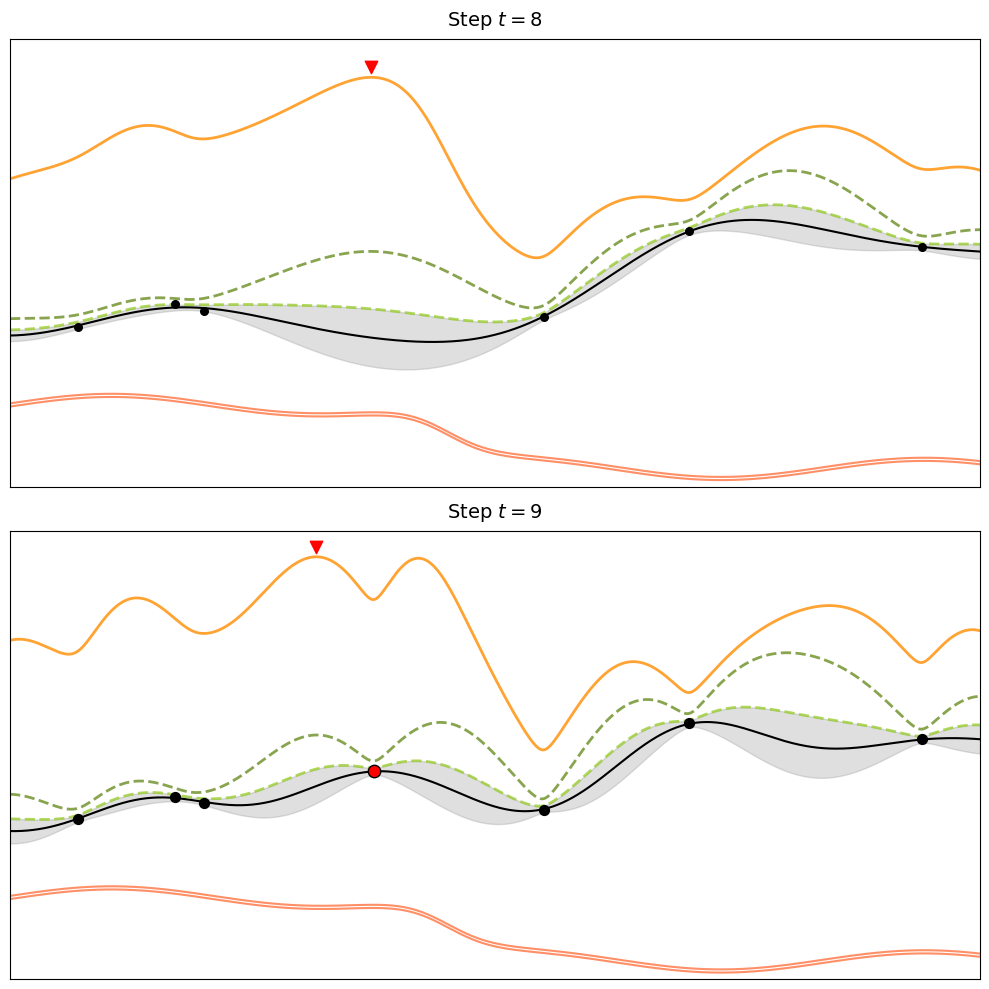

In [89]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C

# 1. FIXED COORDINATES (x, y)
X_fixed = np.array([-0.6, 0.7, 1.7, 2.0, 5.5, 7.0, 9.4, 10.7, 3.75]).reshape(-1, 1)
y_fixed = np.array([4.9, 5.0, 5.7, 5.5, 5.3, 8.0, 7.5, 7.2, 6.5])

# Grid for plotting
X_grid = np.linspace(0, 10, 1000).reshape(-1, 1)

# NEW: The smooth underlying function (e.g., a cost or constraint)
def underlying_fn(x):
    # tanh(5-x) creates the drop at x=5
    # +1 shifts the range from [-1, 1] to [0, 2]
    # sin(1.5x) adds the requested "curves"
    return (1 + np.tanh(2 * (4.5 - x))) + 0.3 * np.sin(1.5 * x) + 0.5

# 2. NOISY GP SETUP
noise_std = 0.1
alpha_val = noise_std**2 

kernel = RBF(length_scale = 0.4, length_scale_bounds = (0.1, 10.0)) * C(10.0)
gp = GaussianProcessRegressor(kernel = kernel, alpha = alpha_val, n_restarts_optimizer = 16, normalize_y=True)

def draw_plot(ax, X_train, y_train, is_step_two = False):
    # Fit the GP
    gp.fit(X_train, y_train)
    y_pred, sigma = gp.predict(X_grid, return_std = True)

    # NEW: Plot the smooth underlying function "underneath"
    ax.plot(X_grid, underlying_fn(X_grid), color = 'orangered', lw = 1.5, ls='-', alpha=0.6, label='Cost/Constraint')
    ax.plot(X_grid, underlying_fn(X_grid) + 0.1, color = 'orangered', lw = 1.5, ls='-', alpha=0.6, label='Cost/Constraint')
    
    # Calculate UCBs for the top plot
    ucb_beta_1 = y_pred + 1.0 * sigma
    ucb_beta_1_2 = y_pred + 3.0 * sigma
    
    # 3. ACQUISITION FUNCTION (Bottom - using beta=1.2 for the peak)
    # Scaled for the bottom area
    acq_plot = (ucb_beta_1_2 - ucb_beta_1_2.min()) / (ucb_beta_1_2.max() - ucb_beta_1_2.min()) * 3 - 5 
    x_next_idx = np.argmax(ucb_beta_1_2)
    x_next = X_grid[x_next_idx]

    # --- MAIN PLOT AREA ---
    # GP Mean Line
    ax.plot(X_grid, y_pred, 'k-', lw = 1.5, label='Posterior Mean')
    
    # Uncertainty Band
    ax.fill_between(X_grid.flatten(), y_pred - sigma, y_pred + sigma, color='grey', alpha=0.25)
    
    # Dashed UCB Lines on top
    ax.plot(X_grid, ucb_beta_1, color = "yellowgreen", ls='--', lw=2.0, alpha=0.8, label=r'UCB ($\beta=1.0$)')
    ax.plot(X_grid, ucb_beta_1_2, color = "olivedrab", ls='--', lw=2.0, alpha=0.8, label=r'UCB ($\beta=1.2$)')

    print(ucb_beta_1_2.shape, underlying_fn(X_grid).squeeze().shape)
    prod = ucb_beta_1_2 * ((underlying_fn(X_grid).squeeze() / 3) + 1)
    print(prod.shape)
    print(np.argmax(prod))
    ax.plot(X_grid, prod, color = 'darkorange', lw = 2.0, ls='-', alpha = 0.8, label='Cost/Constraint')
    ax.scatter([np.argmax(prod)/100], prod[np.argmax(prod)]+ 0.32, color='red', marker='v', s= 80, alpha = 0.99, zorder = 7)
    
    # Data Points (No error bars)
    if is_step_two:
        ax.scatter(X_train[:-1], y_train[:-1], c='black', s=50, zorder=5)
        ax.scatter(X_train[-1], y_train[-1], c='red', edgecolors='black', s=80, zorder=6)
    else:
        ax.scatter(X_train, y_train, c='black', s=30, zorder=5)

    # --- ACQUISITION AREA ---
    ax.fill_between(X_grid.flatten(), -6, acq_plot, color = 'grey', alpha=0.1)
    ax.plot(X_grid, acq_plot, color='grey', lw=1.5)
    ax.plot(x_next, acq_plot[x_next_idx] + 0.5, 'rv', markersize=10)

    # 4. FORMATTING
    ax.set_title(f'Step $t = {len(X_train)}$', fontsize=14, pad=10)
    ax.set_ylim(0, 14)
    ax.set_xlim(0, 10)
    ax.set_xticks([])
    ax.set_yticks([])
    # if not is_step_two: ax.legend(loc='upper left', fontsize=9)

# Create Figure
fig, (ax1, ax2) = plt.subplots(2, 1, figsize = (10, 10))

# Step 1: 8 points
draw_plot(ax1, X_fixed[:-1], y_fixed[:-1], is_step_two = False)

# Step 2: 9 points
draw_plot(ax2, X_fixed, y_fixed, is_step_two = True)

plt.tight_layout()
plt.show()

In [78]:
np.argmax(prod)

NameError: name 'prod' is not defined

In [35]:
underlying_fn(X_grid).shape

(1000, 1)

In [41]:
ucb_beta

NameError: name 'ucb_beta' is not defined

In [ ]:
X_fixed[:-1],

array([[-0.3],
       [ 1.2],
       [ 2.2],
       [ 2.5],
       [ 5. ],
       [ 7. ],
       [ 9.5],
       [10.3]])

In [27]:
print(gp.kernel_.get_params().keys())
gp.kernel_.length_scale

dict_keys(['length_scale', 'length_scale_bounds'])


np.float64(1.0495886247449524)

In [96]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C

# 1. FIXED COORDINATES
X_fixed = np.array([-0.6, 0.7, 1.7, 2.0, 5.5, 7.0, 9.4, 10.7, 3.75]).reshape(-1, 1)
y_fixed = np.array([4.9, 5.0, 5.7, 5.5, 5.3, 8.0, 7.5, 7.2, 6.5])

X_grid = np.linspace(0, 10, 1000).reshape(-1, 1)

def underlying_fn(x):
    return (1 + np.tanh(2 * (4.5 - x))) + 0.3 * np.sin(1.5 * x) + 0.5

# 2. NOISY GP SETUP
noise_std = 0.1
alpha_val = noise_std**2 
kernel = RBF(length_scale=0.4, length_scale_bounds=(0.1, 10.0)) * C(10.0)
gp = GaussianProcessRegressor(kernel=kernel, alpha=alpha_val, n_restarts_optimizer=16, normalize_y=True)

def export_frame(X_train, y_train, filename, is_step_two=False):
    # Create a fresh figure for each individual export
    fig, ax = plt.subplots(figsize=(13, 4))
    
    # Fit the GP
    gp.fit(X_train, y_train)
    y_pred, sigma = gp.predict(X_grid, return_std=True)

    # Plot background functions
    ax.plot(X_grid, underlying_fn(X_grid), color='orangered', lw=1.5, ls='-', alpha=0.4)
    ax.plot(X_grid, underlying_fn(X_grid) + 0.1, color='orangered', lw=1.5, ls='-', alpha=0.4)
    
    ucb_beta_1 = y_pred + 1.0 * sigma
    ucb_beta_1_2 = y_pred + 3.0 * sigma
    
    # Acquisition Area
    acq_plot = (ucb_beta_1_2 - ucb_beta_1_2.min()) / (ucb_beta_1_2.max() - ucb_beta_1_2.min()) * 3 - 5 
    x_next_idx = np.argmax(ucb_beta_1_2)
    x_next = X_grid[x_next_idx]

    # --- MAIN PLOT AREA ---
    ax.plot(X_grid, y_pred, 'k-', lw=1.5)
    ax.fill_between(X_grid.flatten(), y_pred - sigma, y_pred + sigma, color='grey', alpha=0.25)
    
    # UCB Lines
    ax.plot(X_grid, ucb_beta_1, color="yellowgreen", ls='--', lw=2.0, alpha=0.8)
    ax.plot(X_grid, ucb_beta_1_2, color="olivedrab", ls='--', lw=2.0, alpha=0.8)

    # Orange Product Line
    prod = ucb_beta_1_2 * ((underlying_fn(X_grid).squeeze() / 3) + 1)
    ax.plot(X_grid, prod, color='darkorange', lw=2.0, ls='-', alpha=0.8)
    
    # Downward Triangle at the Peak of the orange line
    peak_idx = np.argmax(prod)
    ax.scatter(X_grid[peak_idx], prod[peak_idx] + 0.39, color='red', marker='v', s=80, alpha=0.99, zorder=7)
    
    # Data Points
    if is_step_two:
        ax.scatter(X_train[:-1], y_train[:-1], c='black', s=50, zorder=5)
        ax.scatter(X_train[-1], y_train[-1], c='red', edgecolors='black', s=80, zorder=6)
    else:
        ax.scatter(X_train, y_train, c='black', s=30, zorder=5)

    # Acquisition marker at bottom
    ax.fill_between(X_grid.flatten(), -6, acq_plot, color='grey', alpha=0.1)
    ax.plot(X_grid, acq_plot, color='grey', lw=1.5)
    ax.plot(x_next, acq_plot[x_next_idx] + 0.5, 'rv', markersize=10)

    # --- REMOVE TITLE AND FRAME ---
    ax.axis('off')      # Removes axes, ticks, and the frame (box)
    ax.set_title("")    # Ensures no title is rendered
    
    # Set limits to match previous version
    ax.set_ylim(0, 14)
    ax.set_xlim(0, 10)

    # Save with no whitespace around the plot
    plt.savefig(filename, bbox_inches='tight', pad_inches=0, transparent=True, dpi = 600)
    plt.close(fig)
    print(f"Saved: {filename}")

# Export Step 1 (8 points)
export_frame(X_fixed[:-1], y_fixed[:-1], "step_1.png", is_step_two=False)

# Export Step 2 (9 points)
export_frame(X_fixed, y_fixed, "step_2.png", is_step_two=True)

Saved: step_1.png
Saved: step_2.png


# PBBS

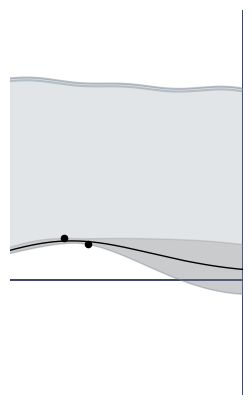

Saved: pbbs.png


<Figure size 640x480 with 0 Axes>

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C
from scipy.stats import norm

# 1. FIXED COORDINATES
X_fixed = np.array([-0.6, 0.7, 1.7, 2.0, 5.5, 7.0, 9.4, 10.7, 3.75]).reshape(-1, 1)
y_fixed = np.array([4.9, 5.0, 5.7, 5.5, 5.3, 8.0, 7.5, 7.2, 6.5])

X_grid = np.linspace(0, 10, 1000).reshape(-1, 1)

def underlying_fn(x):
    # Transition at 4.5 remains, but with a slightly softer slope (1.5)
    step = 1.0 + np.tanh(1.5 * (4.5 - x))
    
    # Combined low-frequency and high-frequency oscillations
    oscillation = 0.3 * np.sin(1.5 * x) + 0.1 * np.cos(5.0 * x)
    
    return ((step + oscillation + 0.5) / 2) + 10

# 2. NOISY GP SETUP
noise_std = 0.1
alpha_val = noise_std**2 
kernel = RBF(length_scale=0.4, length_scale_bounds=(0.1, 10.0)) * C(10.0)
gp = GaussianProcessRegressor(kernel=kernel, alpha=alpha_val, n_restarts_optimizer=16, normalize_y=True)

def export_frame(X_train, y_train, filename, is_step_two=False):
    # Create a fresh figure for each individual export
    fig, ax = plt.subplots(figsize = (3, 5))
    
    # Fit the GP
    gp.fit(X_train, y_train)
    y_pred, sigma = gp.predict(X_grid, return_std=True)

    # Plot background functions
    ax.plot(X_grid, underlying_fn(X_grid), color='slategrey', lw=1.5, ls='-', alpha=0.4)
    ax.plot(X_grid, underlying_fn(X_grid) + 0.1, color='slategrey', lw=1.5, ls='-', alpha=0.4)

    # --- MAIN PLOT AREA ---
    ax.plot(X_grid, y_pred, 'k-', lw=1.0)
    ax.fill_between(X_grid.flatten(), y_pred - sigma, (underlying_fn(X_grid) + 0.1).squeeze(), color='slategrey', alpha = 0.2)
    ax.fill_between(X_grid.flatten(), y_pred - sigma, y_pred + sigma, color='grey', alpha=0.25)

    # color in "possible ice"
    
    # Data Points
    ax.scatter(X_train, y_train, c = 'black', s = 20, zorder = 5)

    ax.axhline(y = 4.2, color = '#141f4d', linestyle = '-', linewidth = 1.2, alpha = 0.99, zorder=0)
    ax.axvline(x = 4.0, color = '#141f4d', linestyle = '-', linewidth = 1.2, alpha = 0.99, zorder=0)


    # --- REMOVE TITLE AND FRAME ---
    ax.axis('off')      # Removes axes, ticks, and the frame (box)
    ax.set_title("")    # Ensures no title is rendered
    
    # Set limits to match previous version
    ax.set_ylim(0, 14)
    ax.set_xlim(1, 4)

    # Save with no whitespace around the plot
    plt.show()
    plt.savefig(filename, bbox_inches='tight', pad_inches=0, transparent=True, dpi = 600)
    plt.close(fig)
    print(f"Saved: {filename}")

# Export Step 1 (8 points)
export_frame(X_fixed[:-1], y_fixed[:-1], "pbbs.png", is_step_two=False)

In [55]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C
from scipy.stats import norm

# 1. FIXED COORDINATES
X_fixed = np.array([-0.6, 0.7, 1.7, 2.0, 5.5, 7.0, 9.4, 10.7, 3.75]).reshape(-1, 1)
y_fixed = np.array([4.9, 5.0, 5.7, 5.5, 5.3, 8.0, 7.5, 7.2, 6.5])

X_grid = np.linspace(0, 10, 1000).reshape(-1, 1)

def underlying_fn(x):
    # Transition at 4.5 remains, but with a slightly softer slope (1.5)
    step = 1.0 + np.tanh(1.5 * (4.5 - x))
    
    # Combined low-frequency and high-frequency oscillations
    oscillation = 0.3 * np.sin(1.5 * x) + 0.1 * np.cos(5.0 * x)
    
    return ((step + oscillation + 0.5) / 2) + 10

# 2. NOISY GP SETUP
noise_std = 0.1
alpha_val = noise_std**2 
kernel = RBF(length_scale=0.4, length_scale_bounds=(0.1, 10.0)) * C(10.0)
gp = GaussianProcessRegressor(kernel=kernel, alpha=alpha_val, n_restarts_optimizer=16, normalize_y=True)

def export_frame(X_train, y_train, filename, is_step_two=False):
    # Create a fresh figure for each individual export
    fig, ax = plt.subplots(figsize = (5, 5))
    
    # Fit the GP
    gp.fit(X_train, y_train)
    y_pred, sigma = gp.predict(X_grid, return_std=True)

    # Plot background functions
    ax.plot(X_grid, underlying_fn(X_grid), color='slategrey', lw=1.5, ls='-', alpha=0.4)
    ax.plot(X_grid, underlying_fn(X_grid) + 0.1, color='slategrey', lw=1.5, ls='-', alpha=0.4)

    # --- MAIN PLOT AREA ---
    ax.plot(X_grid, y_pred, 'k-', lw=1.0)
    ax.fill_between(X_grid.flatten(), y_pred - sigma, (underlying_fn(X_grid) + 0.1).squeeze(), color='slategrey', alpha = 0.2)
    ax.fill_between(X_grid.flatten(), y_pred - sigma, y_pred + sigma, color='grey', alpha=0.25)

    # color in "possible ice"
    
    # Data Points
    ax.scatter(X_train, y_train, c = 'black', s = 20, zorder = 5)

    ax.axhline(y = 4.2, color = '#141f4d', linestyle = '-', linewidth = 1.2, alpha = 0.99, zorder= 3)
    ax.axvline(x = 3.99, color = 'white', linestyle = '-', linewidth = 3.0, alpha = 0.99, zorder = 8)

    # --- REMOVE TITLE AND FRAME ---
    ax.axis('off')      # Removes axes, ticks, and the frame (box)
    ax.set_title("")    # Ensures no title is rendered
    
    # Set limits to match previous version
    ax.set_ylim(0, 14)
    ax.set_xlim(1, 4)

    ax.axvspan(4.0, 5.5, color='white', zorder = 2)

    # ... inside export_frame after gp.predict ...

    # 1. PARAMETERS FOR THE VERTICAL GAUSSIAN
    target_x = 4.0
    idx = np.abs(X_grid - target_x).argmin()
    mu_at_4 = y_pred[idx]
    sigma_at_4 = sigma[idx]

    # Create the PDF curve
    y_span = np.linspace(mu_at_4 - 4*sigma_at_4, mu_at_4 + 4*sigma_at_4, 100)
    pdf_values = norm.pdf(y_span, mu_at_4, sigma_at_4)
    pdf_values = (pdf_values / pdf_values.max()) * 1.0  # Scaled to 0.4 x-units wide

    # 2. COLOR AREA BELOW 4.2 (e.g., Bedrock or Threshold)
    # zorder=0 keeps this behind all GP uncertainty and lines
    # ax.fill_between(X_grid.flatten(), 0, 4.2, color='#ececec', alpha=1.0, zorder=0)

    # 3. PLOT VERTICAL GAUSSIAN (Pointing Right)
    # By using target_x + pdf_values, it grows toward x=5
    # 3. PLOT VERTICAL GAUSSIAN (Pointing Right)
    
    # Fill ONLY the part below 4.2 (e.g., the "Likely Bed" probability)
    ax.fill_betweenx(y_span, 
                    target_x, 
                    target_x + pdf_values, 
                    where=(y_span <= 4.2),
                    color='#141f4d',  # Matching your horizontal line color
                    alpha=0.4, 
                    zorder=4)

    # Optional: Fill the part ABOVE 4.2 in a lighter grey to maintain the silhouette
    ax.fill_betweenx(y_span, 
                    target_x, 
                    target_x + pdf_values, 
                    where=(y_span > 4.2),
                    color='grey', 
                    alpha=0.35, 
                    zorder=4)

    # Draw the full outline so the distribution shape is clear
    ax.plot(target_x + pdf_values, y_span, color='grey', lw=0.8, alpha=0.5, zorder=4)

    # 2. FILL LOWER LEFT QUADRANT (The "Bedrock" region)
    # Using the same blue (#141f4d) and alpha (0.4) as your Gaussian fill
    ax.fill_between(X_grid.flatten(), 0, 4.2, 
                    where=(X_grid.flatten() <= 4.0), 
                    color='#141f4d', 
                    alpha=0.4, 
                    zorder=1)

    prob_below = norm.cdf(4.2, loc=mu_at_4, scale=sigma_at_4)
    print(f"Probability below threshold: {prob_below:.2%}") 

    # 4. ADJUST LIMITS
    ax.set_ylim(0, 14)
    ax.set_xlim(1, 5.4)  # Extended to 4.6 to fit the Gaussian "bump"

    # Save with no whitespace around the plot
    # plt.show()
    plt.savefig(filename, bbox_inches='tight', pad_inches=0, transparent=True, dpi = 600)
    plt.close(fig)
    print(f"Saved: {filename}")

# Export Step 1 (8 points)
export_frame(X_fixed[:-1], y_fixed[:-1], "pbbs.png", is_step_two=False)

Probability below threshold: 34.15%
Saved: pbbs.png
